In [52]:
pip install pandas numpy matplotlib seaborn scipy sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [53]:
import pandas as pd
import numpy as np

df = pd.read_csv(r'C:\Users\HP\OneDrive\CD HomeWork\GitHub\Clinical Trial Analysis Project\chemotherapy_data.csv')

In [54]:
df.head()

,Patient_ID,Age,Sex,BMI,Smoking_Status,Cancer_Type,Genetic_Mutation,Tumor_Stage,Tumor_Size,Metastasis_Status,Chemotherapy_Regimen,Dosage (mg/m²),Cycles_Completed,Nausea_Severity,Neutropenia,Tumor_Response,Overall_Survival_Months
0,P00001,68,Male,31.5,Former,Breast,BRCA1,II,8.8,No,FOLFOX,352.3,5,1,Yes,Stable,88
1,P00002,81,Female,25.8,Former,Lung,KRAS,I,5.4,Yes,CHOP,374.3,6,3,No,Stable,17
2,P00003,58,Male,22.3,Former,Lymphoma,BRCA1,II,3.3,No,ABVD,83.1,5,4,Yes,Partial,59
3,P00004,44,Male,33.6,Never,Lymphoma,EGFR,IV,6.0,No,FOLFOX,58.7,5,3,No,Partial,47
4,P00005,72,Male,23.7,Never,Breast,TP53,III,5.7,No,FOLFOX,429.2,6,2,Yes,Progressive,88


In [55]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

In [56]:
df.columns

Index(['patient_id', 'age', 'sex', 'bmi', 'smoking_status', 'cancer_type',
       'genetic_mutation', 'tumor_stage', 'tumor_size', 'metastasis_status',
       'chemotherapy_regimen', 'dosage_(mg_m²)', 'cycles_completed',
       'nausea_severity', 'neutropenia', 'tumor_response',
       'overall_survival_months'],
      dtype='object')

In [57]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52321 entries, 0 to 52320
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               52321 non-null  object 
 1   age                      52321 non-null  int64  
 2   sex                      52321 non-null  object 
 3   bmi                      52321 non-null  float64
 4   smoking_status           52321 non-null  object 
 5   cancer_type              52321 non-null  object 
 6   genetic_mutation         46990 non-null  object 
 7   tumor_stage              52321 non-null  object 
 8   tumor_size               52321 non-null  float64
 9   metastasis_status        52321 non-null  object 
 10  chemotherapy_regimen     49765 non-null  object 
 11  dosage_(mg_m²)           52321 non-null  float64
 12  cycles_completed         52321 non-null  int64  
 13  nausea_severity          52321 non-null  int64  
 14  neutropenia           

In [58]:
df.isnull().sum()

patient_id                    0
age                           0
sex                           0
bmi                           0
smoking_status                0
cancer_type                   0
genetic_mutation           5331
tumor_stage                   0
tumor_size                    0
metastasis_status             0
chemotherapy_regimen       2556
dosage_(mg_m²)                0
cycles_completed              0
nausea_severity               0
neutropenia                   0
tumor_response                0
overall_survival_months       0
dtype: int64

In [59]:
df["genetic_mutation"] = df["genetic_mutation"].fillna("Unknown")

In [60]:
print(df.head())

  patient_id  age     sex   bmi smoking_status cancer_type genetic_mutation  \
0     P00001   68    Male  31.5         Former      Breast            BRCA1   
1     P00002   81  Female  25.8         Former        Lung             KRAS   
2     P00003   58    Male  22.3         Former    Lymphoma            BRCA1   
3     P00004   44    Male  33.6          Never    Lymphoma             EGFR   
4     P00005   72    Male  23.7          Never      Breast             TP53   

  tumor_stage  tumor_size metastasis_status chemotherapy_regimen  \
0          II         8.8                No               FOLFOX   
1           I         5.4               Yes                 CHOP   
2          II         3.3                No                 ABVD   
3          IV         6.0                No               FOLFOX   
4         III         5.7                No               FOLFOX   

   dosage_(mg_m²)  cycles_completed  nausea_severity neutropenia  \
0           352.3                 5             

In [61]:
df["chemotherapy_regimen"] = df["chemotherapy_regimen"].fillna("Not Assigned")


In [62]:
print(df.isnull().sum())

patient_id                 0
age                        0
sex                        0
bmi                        0
smoking_status             0
cancer_type                0
genetic_mutation           0
tumor_stage                0
tumor_size                 0
metastasis_status          0
chemotherapy_regimen       0
dosage_(mg_m²)             0
cycles_completed           0
nausea_severity            0
neutropenia                0
tumor_response             0
overall_survival_months    0
dtype: int64


In [63]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 30, 45, 60, 75, 100],
    labels=["<30", "30-45", "46-60", "61-75", "75+"]
)

In [64]:
df["positive_response"] = df["tumor_response"].isin(["Complete", "Partial"]).astype(int)

In [65]:
df["severe_side_effect"] = (df["nausea_severity"] >= 4).astype(int)

In [66]:
df["high_risk_patient"] = (
    (df["tumor_stage"].isin(["Stage III", "Stage IV"])) |
    (df["metastasis_status"] == "Yes") |
    (df["severe_side_effect"] == 1)
).astype(int)

In [67]:
print(df.isnull().sum())

patient_id                 0
age                        0
sex                        0
bmi                        0
smoking_status             0
cancer_type                0
genetic_mutation           0
tumor_stage                0
tumor_size                 0
metastasis_status          0
chemotherapy_regimen       0
dosage_(mg_m²)             0
cycles_completed           0
nausea_severity            0
neutropenia                0
tumor_response             0
overall_survival_months    0
age_group                  0
positive_response          0
severe_side_effect         0
high_risk_patient          0
dtype: int64


In [68]:
print(df.head())

  patient_id  age     sex   bmi smoking_status cancer_type genetic_mutation  \
0     P00001   68    Male  31.5         Former      Breast            BRCA1   
1     P00002   81  Female  25.8         Former        Lung             KRAS   
2     P00003   58    Male  22.3         Former    Lymphoma            BRCA1   
3     P00004   44    Male  33.6          Never    Lymphoma             EGFR   
4     P00005   72    Male  23.7          Never      Breast             TP53   

  tumor_stage  tumor_size metastasis_status  ... dosage_(mg_m²)  \
0          II         8.8                No  ...          352.3   
1           I         5.4               Yes  ...          374.3   
2          II         3.3                No  ...           83.1   
3          IV         6.0                No  ...           58.7   
4         III         5.7                No  ...          429.2   

   cycles_completed  nausea_severity  neutropenia tumor_response  \
0                 5                1          Yes     

In [69]:
print(df["tumor_response"].value_counts())

tumor_response
Partial        20925
Stable         15688
Complete       10501
Progressive     5207
Name: count, dtype: int64


In [70]:
print(df["chemotherapy_regimen"].value_counts())

chemotherapy_regimen
FOLFOX          15699
ABVD            13052
CHOP            10639
Gemcitabine     10375
Not Assigned     2556
Name: count, dtype: int64


In [71]:
print(df["sex"].value_counts())
print(df["cancer_type"].value_counts())
print(df["tumor_stage"].value_counts())

sex
Female    26368
Male      25953
Name: count, dtype: int64
cancer_type
Colon       10522
Leukemia    10478
Lymphoma    10469
Breast      10458
Lung        10394
Name: count, dtype: int64
tumor_stage
II     18203
III    13221
I      13045
IV      7852
Name: count, dtype: int64


In [72]:
df.columns

Index(['patient_id', 'age', 'sex', 'bmi', 'smoking_status', 'cancer_type',
       'genetic_mutation', 'tumor_stage', 'tumor_size', 'metastasis_status',
       'chemotherapy_regimen', 'dosage_(mg_m²)', 'cycles_completed',
       'nausea_severity', 'neutropenia', 'tumor_response',
       'overall_survival_months', 'age_group', 'positive_response',
       'severe_side_effect', 'high_risk_patient'],
      dtype='object')

In [73]:
total_patients = len(df)
average_age = df["age"].mean()
average_bmi = df["bmi"].mean()
average_survival = df["overall_survival_months"].mean()
response_rate = df["positive_response"].mean() * 100
severe_side_effect_rate = df["severe_side_effect"].mean() * 100
metastasis_rate = (df["metastasis_status"] == "Yes").mean() * 100


In [74]:
df.head(10)

,patient_id,age,sex,bmi,smoking_status,cancer_type,genetic_mutation,tumor_stage,tumor_size,metastasis_status,...,dosage_(mg_m²),cycles_completed,nausea_severity,neutropenia,tumor_response,overall_survival_months,age_group,positive_response,severe_side_effect,high_risk_patient
0,P00001,68,Male,31.5,Former,Breast,BRCA1,II,8.8,No,...,352.3,5,1,Yes,Stable,88,61-75,0,0,0
1,P00002,81,Female,25.8,Former,Lung,KRAS,I,5.4,Yes,...,374.3,6,3,No,Stable,17,75+,0,0,1
2,P00003,58,Male,22.3,Former,Lymphoma,BRCA1,II,3.3,No,...,83.1,5,4,Yes,Partial,59,46-60,1,1,1
3,P00004,44,Male,33.6,Never,Lymphoma,EGFR,IV,6.0,No,...,58.7,5,3,No,Partial,47,30-45,1,0,0
4,P00005,72,Male,23.7,Never,Breast,TP53,III,5.7,No,...,429.2,6,2,Yes,Progressive,88,61-75,0,0,0
5,P00006,37,Male,35.0,Never,Breast,KRAS,III,9.2,No,...,149.9,6,3,Yes,Partial,68,30-45,1,0,0
6,P00007,50,Male,31.2,Never,Lung,Unknown,IV,3.6,No,...,530.4,4,2,No,Stable,106,46-60,0,0,0
7,P00008,68,Female,29.8,Current,Colon,TP53,II,8.0,No,...,90.7,1,3,No,Partial,34,61-75,1,0,0
8,P00009,48,Male,18.7,Never,Lymphoma,TP53,II,3.4,No,...,312.2,7,2,No,Partial,104,46-60,1,0,0
9,P00010,52,Female,25.9,Current,Leukemia,KRAS,II,9.4,Yes,...,573.1,4,1,Yes,Complete,112,46-60,1,0,1


In [75]:
print("Total Patients:", total_patients)
print("Average Age:", round(average_age, 2))
print("Average BMI:", round(average_bmi, 2))
print("Average Survival Months:", round(average_survival, 2))
print("Response Rate:", round(response_rate, 2), "%")
print("Severe Side Effect Rate:", round(severe_side_effect_rate, 2), "%")
print("Metastasis Rate:", round(metastasis_rate, 2), "%")

Total Patients: 52321
Average Age: 57.05
Average BMI: 26.75
Average Survival Months: 62.53
Response Rate: 60.06 %
Severe Side Effect Rate: 20.1 %
Metastasis Rate: 29.92 %


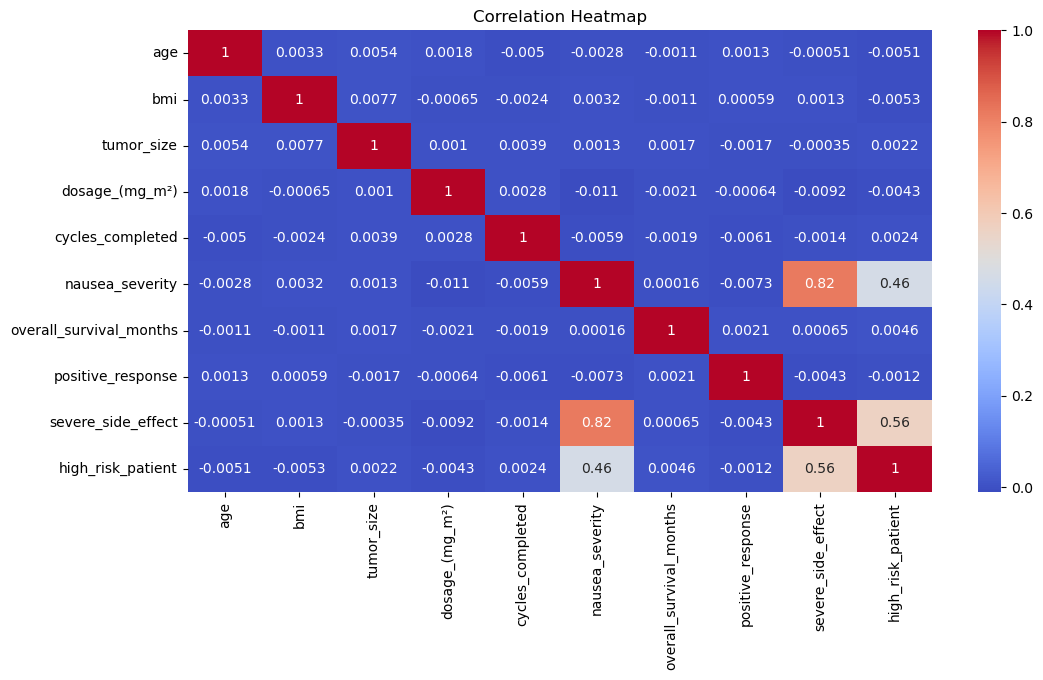

In [86]:
correlation = df.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [87]:
print(df.describe())

                age           bmi    tumor_size  dosage_(mg_m²)  \
count  52321.000000  52321.000000  52321.000000    52321.000000   
mean      57.052063     26.746633      5.493576      325.349055   
std       15.872875      4.755060      2.594122      158.583426   
min       30.000000     18.500000      1.000000       50.000000   
25%       43.000000     22.600000      3.200000      187.400000   
50%       57.000000     26.800000      5.500000      325.700000   
75%       71.000000     30.900000      7.700000      463.300000   
max       84.000000     35.000000     10.000000      600.000000   

       cycles_completed  nausea_severity  overall_survival_months  \
count      52321.000000     52321.000000             52321.000000   
mean           4.000306         2.400680                62.529233   
std            1.995503         1.283944                32.865937   
min            1.000000         1.000000                 6.000000   
25%            2.000000         1.000000           

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

response_by_regimen = (
    df.groupby("chemotherapy_regimen")["positive_response"]
    .mean()
    .reset_index()
)

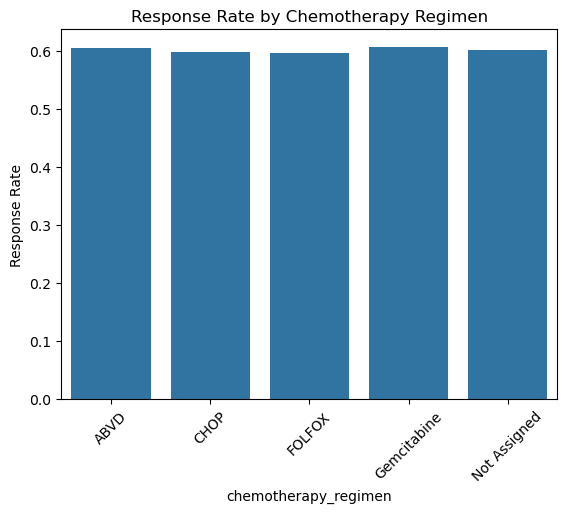

In [90]:
sns.barplot(data=response_by_regimen, x="chemotherapy_regimen", y="positive_response")
plt.xticks(rotation=45)
plt.title("Response Rate by Chemotherapy Regimen")
plt.ylabel("Response Rate")
plt.show()

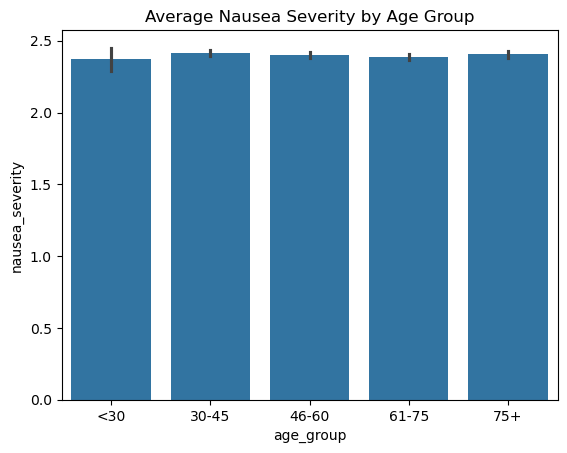

In [91]:
sns.barplot(data=df, x="age_group", y="nausea_severity")
plt.title("Average Nausea Severity by Age Group")
plt.show()

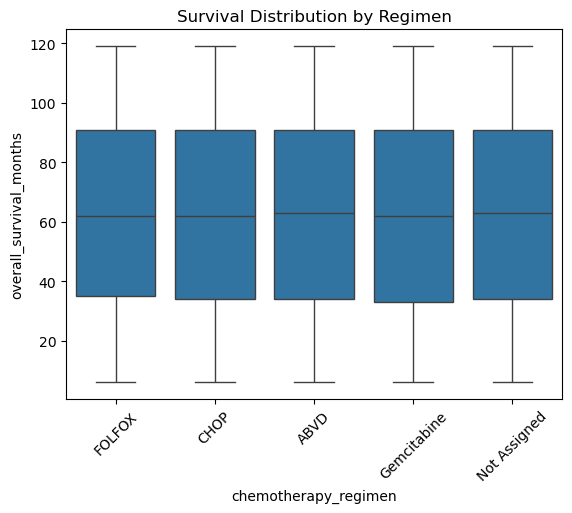

In [92]:
sns.boxplot(data=df, x="chemotherapy_regimen", y="overall_survival_months")
plt.xticks(rotation=45)
plt.title("Survival Distribution by Regimen")
plt.show()

In [93]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["chemotherapy_regimen"], df["tumor_response"])
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 14.37589365662752
p-value: 0.2773511074810217


In [94]:
from scipy.stats import f_oneway

groups = [
    group["overall_survival_months"].dropna()
    for name, group in df.groupby("chemotherapy_regimen")
]

In [95]:
f_stat, p_value = f_oneway(*groups)

In [96]:
print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.9200285863915485
p-value: 0.4510334167525498


In [97]:
pip install sqlalchemy psycopg2-binary

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [99]:
from sqlalchemy import create_engine

username = "postgres"      
password = "Wahida11" 
host = "localhost"         
port = "5432"              
database = "Clinical_Trail"    

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

table_name = "clinical_trials"   
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'clinical_trials' in database 'Clinical_Trail'.
